In [1]:
# notebook imports
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit_ibm_runtime import QiskitRuntimeService

# simulator imports
from qiskit_aer import Aer
from qiskit import transpile
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector

import os

# load environment variables from .env file
from dotenv import load_dotenv
load_dotenv()

# load Qiskit API token from .env file
QISKIT_API_TOKEN = os.getenv("QISKIT_API_TOKEN")
QiskitRuntimeService.save_account(token=QISKIT_API_TOKEN, overwrite=True)

# import qutip; for modelling quantum systems
import qutip

## Anti-commuting Property
- Input: A qubit in the |1⟩ state
- Apply Pauli-X, then Pauli-Z; then reverse the order
- Observe Statevector and Q-Sphere

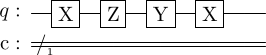


Total count for 00 and 11 are: {'1 0': 1024}


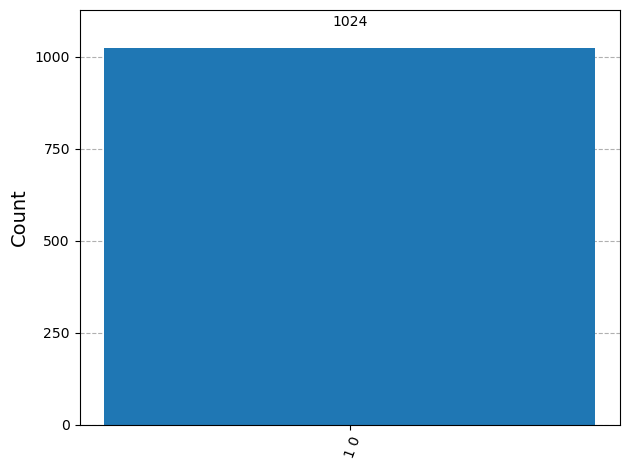

In [9]:
qreg_q = QuantumRegister(1, 'q')
creg_c = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(qreg_q, creg_c)

circuit.x(0)  # Apply X gate to qubit 0

# input complete, initialized to |1⟩. 

circuit.z(0)
circuit.y(0)
circuit.x(0)

display(circuit.draw('latex'))

circuit.measure_all()

simulator = Aer.get_backend('aer_simulator')
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts(compiled_circuit)
print("\nTotal count for 00 and 11 are:", counts)
plot_histogram(counts)

